In [12]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense
)

In [13]:
input_texts = [
    "hello",
    "good morning",
    "thank you",
    "good night"
]

target_texts = [
    "bonjour",
    "bon matin",
    "merci",
    "bonne nuit"
]

In [14]:
input_texts = [
    "hello",
    "good morning",
    "thank you",
    "good night"
]

target_texts = [
    "bonjour",
    "bon matin",
    "merci",
    "bonne nuit"
]

In [15]:
input_chars = sorted(
    set("".join(input_texts))
)

target_chars = sorted(
    set("".join(target_texts))
)

input_vocab_size = len(input_chars)
target_vocab_size = len(target_chars)

input_char_to_int = {
    char: i
    for i, char in enumerate(input_chars)
}

target_char_to_int = {
    char: i
    for i, char in enumerate(target_chars)
}

In [16]:
max_input_length = max(
    len(text)
    for text in input_texts
)

max_target_length = max(
    len(text)
    for text in target_texts
)

encoder_input_data = np.zeros(
    (
        len(input_texts),
        max_input_length,
        input_vocab_size
    )
)

decoder_input_data = np.zeros(
    (
        len(input_texts),
        max_target_length,
        target_vocab_size
    )
)

decoder_target_data = np.zeros(
    (
        len(input_texts),
        max_target_length,
        target_vocab_size
    )
)

In [17]:
for i, input_text in enumerate(input_texts):

    for t, char in enumerate(input_text):

        encoder_input_data[
            i,
            t,
            input_char_to_int[char]
        ] = 1

In [18]:
encoder_inputs = Input(
    shape=(None, input_vocab_size)
)

encoder_lstm = LSTM(
    128,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(
    encoder_inputs
)

encoder_states = [
    state_h,
    state_c
]

In [19]:
decoder_inputs = Input(
    shape=(None, target_vocab_size)
)

decoder_lstm = LSTM(
    128,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs,
    initial_state=encoder_states
)

In [20]:
decoder_dense = Dense(
    target_vocab_size,
    activation="softmax"
)

decoder_outputs = decoder_dense(
    decoder_outputs
)

In [21]:
model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

In [22]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=2,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 823ms/step - accuracy: 0.1000 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/50

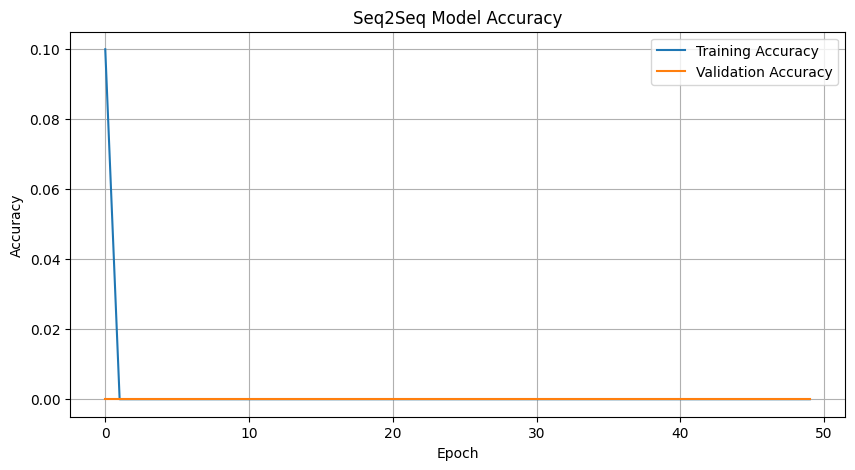

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Seq2Seq Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [25]:
loss, accuracy = model.evaluate(
    [encoder_input_data, decoder_input_data],
    decoder_target_data
)

print("Loss:", loss)
print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Loss: 0.0
Accuracy: 0.0
